# LLM-Driven Personal Financial Assistant

**Technical report and reproducible experiments**

This document accompanies the repository implementation. Each section maps to project design, integration, prompting, domain logic, evaluation and critical analysis.

---


## 1. FinAssist

### 1.1 System Overview

The **LLM-Driven Personal Financial Assistant (FinAssist)** is a Streamlit-based application that guides users through a **structured, slot-filling dialogue** (`SessionSlots` in `src/dialogue/slots.py`). A local LLM backend (`MockLLMBackend` or `HFLocalBackend`) is used for two key tasks: **JSON-based slot extraction** and **structured recommendation generation**.

Once all required slots are populated, the system generates a recommendation constrained by the `FinancialRecommendation` schema (`src/finassist/schemas.py`). To improve reliability, the design incorporates a **hybrid reasoning approach**: critical financial calculations—such as debt feasibility—are computed deterministically in Python (`src/finassist/debt_calculations.py`) and injected into the LLM prompt. This ensures that numerical reasoning is **grounded in explicit computation** rather than left to the probabilistic behavior of the language model.

---

### 1.2 Problem Statement

Unstructured interaction with causal language models often results in:
- inconsistent output formats  
- unreliable numerical reasoning  
- hallucinated financial values  

These limitations are particularly problematic in financial contexts, where correctness and interpretability are essential.

This project addresses these challenges through:
- **staged information collection** (dialogue-driven slot filling)  
- **schema-constrained generation** (validated structured outputs)  
- **deterministic financial calculations** (Python-based feasibility checks)  

By combining these techniques, the system reduces dependence on the LLM for arithmetic reasoning and improves the **consistency, traceability, and reliability** of generated recommendations.

---

### 1.3 Scope

The implemented system includes:
- a Streamlit-based user interface  
- a dialogue state machine for structured interaction  
- local Hugging Face model inference with optional 4-bit quantization  
- a mock backend for testing and rapid iteration  
- schema-validated JSON recommendation generation  
- deterministic debt calculation and injection into prompts  
- batch evaluation using predefined fixtures and scoring metrics  

The following are **explicitly out of scope**:
- retrieval-augmented generation (RAG)  
- live financial data or market feeds  
- production-grade compliance, regulation, or advisory systems  

Additionally, the system includes optional support for **LoRA-based fine-tuning** (`scripts/train_lora.py`), though this is not enabled in the default configuration.

---

### Analysis

The design adopts a **structured interaction paradigm** to address the inherent limitations of LLM-based systems.

- **Rationale:**  
  Staged slot collection transforms unstructured user input into a **typed and validated user profile**, enabling more controlled and interpretable recommendation generation.

- **Benefit:**  
  This significantly improves **output stability**, **JSON validity**, and **auditability**, which are critical for both evaluation and user trust.

- **Trade-off:**  
  The structured dialogue increases user interaction overhead and introduces dependency on extraction accuracy. However, this is mitigated through:
  - controlled retries (`extraction_retry_limit`)  
  - user correction via “Quick edit” (`src/app/chat_ui.py`)  

Overall, the system prioritizes **reliability and transparency over conversational flexibility**, which is appropriate for financial decision-support contexts.

## 2. System Architecture

The codebase follows a **modular separation of concerns**, ensuring that the UI does not embed business logic. Core orchestration is handled by the `DialogueEngine`, validation is delegated to `validators.py`, and presentation logic is defined in `guided_flow.py`. This design improves maintainability, testability, and clarity of system responsibilities.

| Layer | Responsibility | Primary modules |
|------|----------------|-----------------|
| UI | Pages, sidebar, chat interaction | `src/app/streamlit_app.py`, `src/app/chat_ui.py`, `src/app/pages/` |
| Dialogue | State transitions, slot merging, JSON extraction | `src/dialogue/state_machine.py`, `guided_flow.py`, `validators.py` |
| LLM | Text generation backends | `src/llm/mock_backend.py`, `hf_local.py` |
| Finance | Deterministic metrics, schema parsing, justification | `src/finassist/debt_calculations.py`, `schemas.py`, `justification.py` |
| Evaluation | Batch testing and scoring | `src/evaluation/run_eval.py`, `configs/evaluation.yaml` |

---



### 2.1 Data Flow

<img src= "Diagram-1.jpg" alt="isolated">
---


### 2.3 Environment bootstrap

**Rubric alignment:** Demonstrates **reproducibility** through consistent paths, environment configuration, and parity between notebook and CLI execution.

The function `project_root()` (defined in `src/utils/config_loader.py`) ensures that all file paths are resolved relative to the repository root, regardless of where the notebook is launched (e.g., `notebooks/` or project root). This prevents path inconsistencies across different execution contexts.

To mirror the runtime behavior of the application, the notebook prepends `src/` to `sys.path`, aligning with the configuration `pythonpath = ["src"]` in `pyproject.toml`. This ensures that module imports behave identically to CLI execution (e.g., `python -m evaluation.run_eval`).

**Kernel configuration:**  
The notebook must use the same virtual environment as the application (installed via `pip install -e .`). This guarantees consistent resolution of dependencies such as `torch`, `transformers`, and `peft`, and avoids discrepancies between development and evaluation environments.

---

### Analysis

- **Rationale:**  
  Centralizing path resolution through `project_root()` eliminates environment-dependent file path issues, a common source of reproducibility errors.

- **Benefit:**  
  Ensures **consistent execution across notebook, CLI, and Streamlit app**, enabling reliable evaluation and easier debugging.

- **Trade-off:**  
  Incorrect kernel selection may lead to import errors or CUDA/device mismatches. For reproducibility, the kernel name and environment should be explicitly documented in the submission.

---



In [14]:
from __future__ import annotations

import sys
from pathlib import Path

_here = Path.cwd()
for candidate in (_here, _here.parent):
    if (candidate / "src" / "utils" / "config_loader.py").is_file():
        p = str(candidate / "src")
        if p not in sys.path:
            sys.path.insert(0, p)
        break

from utils.config_loader import load_yaml, project_root

ROOT = project_root()
assert (ROOT / "configs" / "models.yaml").is_file(), (
    f"Expected configs/models.yaml under {ROOT} — run the notebook from the repo or set up src/ imports."
)
print("Project root:", ROOT)
print("OK: configs/models.yaml found.")


Project root: C:\Users\Partho\Desktop\NLP\assignment-2
OK: configs/models.yaml found.


## 3. Model Selection and Justification

### 3.1 Checkpoints in Use

The system uses **public instruction-tuned models** from Hugging Face. These models are pre-aligned for instruction following; this project **does not train base models**, but loads them via `transformers` for local inference.

The model configuration is defined in `configs/models.yaml`:

- **Primary (`hf_primary`):** `Qwen/Qwen2.5-1.5B-Instruct`  
  Selected for its strong instruction-following capability, relatively stable JSON formatting, and suitability for **4-bit local deployment**.

- **Comparison (`hf_alt`):** `microsoft/Phi-3-mini-4k-instruct`  
  Chosen as a contrasting instruct model from a different model family to enable **meaningful A/B evaluation** under the same pipeline and prompts.

> Note: Very small models (e.g., TinyLlama) may be used for lightweight debugging under strict VRAM constraints but are not suitable for structured financial recommendation tasks and are therefore excluded from the final comparison.

---

### 3.2 Hardware Rationale

The choice of sub-2B parameter models reflects practical deployment constraints:

- compatibility with **consumer-grade GPUs**  
- support for **4-bit NF4 quantization** in `hf_local.py`  
- reduced memory footprint and faster inference  

This design prioritizes **local reproducibility and accessibility** over raw model capability. The system does not claim performance parity with larger cloud-hosted models.

---

### 3.3 Adapter Support (LoRA)

The system includes support for **parameter-efficient fine-tuning (LoRA)** via PEFT. If `adapter_path` is set in `configs/models.yaml`, the base model is wrapped using `PeftModel.from_pretrained`.

In the default configuration:
- `adapter_path = null`  
- no LoRA adapter is active  

This allows the system to run without requiring additional training, while still supporting extensibility for domain adaptation.

---


---

### Analysis

- **Rationale:**  
  Sub-2B instruction-tuned models provide a practical balance between capability and resource constraints, enabling fully local deployment within coursework limitations.

- **Benefit:**  
  The system remains **reproducible, lightweight, and easy to evaluate**, with no dependency on external APIs or proprietary models.

- **Trade-off:**  
  Smaller models exhibit weaker reasoning and are more prone to **JSON formatting errors or hallucinated values**. These limitations are mitigated through:
  - schema validation (`FinancialRecommendation`)  
  - structured prompting  
  - deterministic financial calculations  

Additionally, comparing two distinct model families (Qwen vs Phi-3) provides **empirical insight into model behavior differences**, strengthening the evaluation component of the project.

---


In [15]:
models_cfg = load_yaml("configs/models.yaml")
primary = models_cfg.get("primary", {})
comp = models_cfg.get("comparison", {})

print("=== Primary HF ===")
print("base_model_id:", primary.get("base_model_id"))
print("adapter_path:", primary.get("adapter_path"))
print("load_in_4bit:", primary.get("load_in_4bit"), "| torch_dtype:", primary.get("torch_dtype"))

print("\n=== Comparison HF (hf_alt) ===")
print("alt_base_model_id:", comp.get("alt_base_model_id"))
print("alt_adapter_path:", comp.get("alt_adapter_path"))


=== Primary HF ===
base_model_id: Qwen/Qwen2.5-1.5B-Instruct
adapter_path: None
load_in_4bit: True | torch_dtype: bfloat16

=== Comparison HF (hf_alt) ===
alt_base_model_id: microsoft/Phi-3-mini-4k-instruct
alt_adapter_path: None


**Takeaway.** Same orchestration (`src/dialogue/state_machine.py`); only `HFLocalBackend(use_primary=…)` in `src/llm/hf_local.py` switches checkpoints. `adapter_path: null` in `configs/models.yaml` means base weights only unless a trained adapter path is set.

---


## 4. LLM Configuration and Deployment

### 4.1 Loading and Inference

The system uses `HFLocalBackend` (`src/llm/hf_local.py`) to load Hugging Face models via `AutoModelForCausalLM` and `AutoTokenizer`.

Key configuration features include:
- **4-bit quantization (NF4)** using `BitsAndBytesConfig` for reduced VRAM usage  
- automatic device mapping (`device_map="auto"`) for GPU/CPU compatibility  
- fallback to `float16` if `bfloat16` is not supported by the hardware  
- use of `apply_chat_template` for consistent prompt formatting  

Both dialogue extraction and recommendation generation use a **low temperature (0.2)**, configured in `state_machine.py`, to encourage **deterministic and stable outputs**, particularly for structured JSON generation.

---

### 4.2 Hugging Face Checkpoints in Configuration

| Config key | Role |
|------------|------|
| `primary.base_model_id` | Default Hugging Face model for the main application (`hf_primary`) |
| `comparison.alt_base_model_id` | Alternate model for A/B evaluation (`hf_alt`) |

Both models are loaded through the same backend (`HFLocalBackend`), ensuring that differences in output are attributable to the **model itself**, rather than changes in the inference pipeline.

---

### 4.3 Token and Memory Configuration

The system defines separate token limits for different stages:

- **Extraction stage:** shorter prompts, lower token limits  
- **Recommendation stage:** longer prompts due to embedded:
  - user profile (slot JSON)  
  - deterministic calculation payload  

To support this, the configuration includes:
- increased `max_input_tokens` for recommendation  
- separate `max_new_tokens` caps  
- a **low-VRAM mode** for reduced memory environments  

The setting `truncation_side: "left"` ensures that, when prompts exceed the maximum token limit, the **beginning of the prompt is truncated** while preserving the **final JSON schema and calculation context**.

---

### Analysis

- **Rationale:**  
  Recommendation prompts are significantly longer than extraction prompts due to embedded structured data. Token limits and truncation policies are required to prevent out-of-memory (OOM) errors during local inference.

- **Benefit:**  
  Preserving the **suffix of the prompt** (including schema and calculation payload) ensures that the model retains access to the most critical constraints for structured output generation.

- **Trade-off:**  
  Truncating the prefix may remove earlier contextual details (e.g., parts of the user profile). However, this is acceptable as long as **key numerical and structural constraints** remain intact in the retained portion of the prompt.

---

In [16]:
rec = models_cfg.get("recommendation", {})
low = models_cfg.get("low_vram", {})
print("Recommendation generation caps:", dict(rec))
print("Low VRAM sidebar caps (general):", dict(low))
# truncation_side=left for recommendation keeps the tail of long prompts (schema contract)


Recommendation generation caps: {'max_new_tokens': 1536, 'low_vram_max_new_tokens': 768, 'max_input_tokens': 4096, 'low_vram_max_input_tokens': 3072, 'truncation_side': 'left'}
Low VRAM sidebar caps (general): {'max_new_tokens': 256, 'max_input_tokens': 1536}


**Takeaway.** Recommendation uses higher `max_input_tokens` than generic dialogue (`configs/models.yaml`); `truncation_side: left` favours keeping the JSON contract at the prompt tail. Low VRAM caps trade length for fit on small GPUs.

---

## 5. Fine-tuning discussion (LoRA / PEFT) *(optional enhancement)*

### 5.1 What the codebase supports

Training is implemented (`scripts/train_lora.py`, `configs/training.yaml`): QLoRA-style settings (`load_in_4bit`, LoRA ranks on attention projections). At inference, `HFLocalBackend.load()` merges a PEFT adapter when `primary.adapter_path` resolves to an existing directory.

### 5.2 What is active in a default checkout

With `adapter_path: null` in `configs/models.yaml` and no weights under `models/lora_adapter`, the system runs **base instruct weights only**—a defensible baseline when training is out of scope, while still documenting the supported path.

### 5.3 Future Work

Domain-specific JSON or dialogue data in `data/processed/` could specialise tone and slot adherence; the training config already points to `train.jsonl` / `val.jsonl` paths.


**Analysis.**   
*Rationale:* QLoRA hooks satisfy coursework expectations without mandating a full training budget.   
*Benefit:* optional specialisation when data exist.   
*Trade-off:* with `adapter_path: null`, behaviour is **generic instruct**—honest for marking if training was not run.

---


In [17]:
training_cfg = load_yaml("configs/training.yaml")
default_out = ROOT / training_cfg.get("output_dir", "models/lora_adapter")
print("training.yaml base_model_id:", training_cfg.get("base_model_id"))
print("lora_r / lora_alpha:", training_cfg.get("lora_r"), training_cfg.get("lora_alpha"))
print("Default LoRA output_dir:", default_out)
print("Adapter directory exists:", default_out.is_dir())


training.yaml base_model_id: Qwen/Qwen2.5-1.5B-Instruct
lora_r / lora_alpha: 16 32
Default LoRA output_dir: C:\Users\Partho\Desktop\NLP\assignment-2\models\lora_adapter
Adapter directory exists: False


**Takeaway.** Missing `models/lora_adapter` and `null` adapters corroborate **no LoRA** at inference; verify `HFLocalBackend.load()` logs if adapters are added later.

---

## 6. Dialogue System

### 6.1 Stages and Slot Groups

The dialogue system is implemented as a staged state machine using `DialogueState` (`src/dialogue/slots.py`). It enforces a structured interaction flow across four **content stages**, followed by recommendation generation:

1. **DEFINE_TASK** — captures `task_definition.summary` and `goal`  
2. **COLLECT_PERSONAL** — captures age, employment, region, dependents, and risk (`personal_filled`)  
3. **REQUIREMENTS** — captures budget hint, time horizon, and liquidity needs (`requirements_filled`)  
4. **PREFERENCES** — captures product preferences and/or ethical constraints (`preferences_filled`)  

State progression is not stored as a simple flag. Instead, it is **recomputed dynamically** from slot completeness using `compute_state_from_slots`. This avoids reliance on fragile state memory and ensures that the system reflects the **true underlying data state** at all times.

---

### 6.2 Extraction Pipeline

Slot extraction is handled through a structured prompting approach using `dialogue_collect.jinja2`. The model is instructed to return a single JSON object containing `slot_updates`, organized under keys such as `task_definition`, `personal_summary`, and others.

The extraction pipeline in `state_machine.py`:
- merges new slot updates into the existing state  
- coerces values into consistent string representations  
- validates structure against expected schema  
- applies `_fallback_extract_slots` if JSON parsing fails  

This fallback mechanism ensures that extraction failures are handled explicitly and transparently, rather than relying on implicit or hidden recovery logic.

---

### 6.3 Trade-offs

The use of LLM-based structured extraction offers flexibility and generality compared to rule-based methods (e.g., regex pipelines). However, it introduces **dependency on model performance**, particularly for ambiguous or incomplete user inputs.

Failure modes include:
- partial slot extraction  
- incorrect field mapping  
- invalid JSON outputs  

To mitigate this, the system:
- enforces a retry limit (`extraction_retry_limit` in `configs/dialogue.yaml`)  
- allows manual correction via the Streamlit **Quick edit** interface  

---

### Analysis

- **Rationale:**  
  Structured JSON-based extraction provides a clear interface between user input and system state, enabling validation and controlled downstream processing.

- **Benefit:**  
  The use of `compute_state_from_slots` ensures that dialogue progression is **data-driven rather than state-driven**, reducing inconsistencies between UI flow and actual slot completeness.

- **Trade-off:**  
  The system remains dependent on LLM extraction quality. While retries and manual overrides mitigate failures, this introduces friction in the user experience and limits robustness in production scenarios.

---


In [18]:
from dialogue.slots import SessionSlots, TaskDefinition, PersonalInfo, FinancialRequirements, FinancialPreferences
from dialogue.validators import compute_state_from_slots

# Synthetic “extraction-heavy” session: many fields set at once
slots = SessionSlots(
    task_definition=TaskDefinition(summary="Pay off credit card debt", goal="Clear $6,000 within 12 months"),
    personal_summary=PersonalInfo(
        age_range="25-34",
        employment_status="employed",
        country_region="US",
        dependents="0",
        risk_tolerance="medium",
        notes="First-time using a structured planner",
    ),
    financial_requirements=FinancialRequirements(
        monthly_budget_hint="$200 per month",
        time_horizon_months="12 months",
        liquidity_needs="keep $1k cash buffer",
        constraints="no balance transfers",
    ),
    financial_preferences=FinancialPreferences(
        ethical_constraints="none",
        product_preferences="snowball or avalanche apps OK",
        automation_comfort="medium",
    ),
)
state, reasons = compute_state_from_slots(slots)
print("Computed state:", state)
for r in reasons:
    print(" -", r)


Computed state: DialogueState.RECOMMEND
 - ok: task_definition
 - ok: personal_summary
 - ok: financial_requirements
 - ok: financial_preferences


**Takeaway.** Expect `RECOMMEND` when all slot groups satisfy `validators.py`; the `reasons` list aids debugging. A different state here would indicate a regression in `compute_state_from_slots`.

---


## 7. Prompt engineering

**Rubric alignment:** **prompt design and prompting strategies** (zero-shot, few-shot, CoT); critical assessment of what is *actually* wired.

### 7.1 Techniques in brief 

| Technique | Idea | Typical trade-off |
|-----------|------|-------------------|
| Zero-shot | Instructions only | Low token cost; format drift possible |
| Few-shot | In-prompt exemplars | Better format anchoring; longer context |
| Chain-of-thought | Hidden or explicit reasoning steps | May improve logic; increases length and truncation risk |

### 7.2 How this project uses them (two pipelines)

1. **Slot extraction (dialogue turns):** a **single** template — `src/llm/prompts/dialogue_collect.jinja2` — returns JSON `slot_updates`. The `techniques/*.txt` files are **not** prepended here.
2. **Recommendations:** `generate_recommendations` renders **only** `recommend.jinja2`. The `technique` argument is **discarded** (`_ = technique` in `state_machine.py`). Files `zero_shot.txt`, `few_shot.txt`, `cot.txt` document **intent** for benchmarks and future work, but **do not** alter the recommendation prompt in the current code path.

### 7.3 Limitation

Reported **technique** in `run_eval` or the Benchmarks UI is **metadata**, not a controlled prompt ablation.   
**Analytical claim:** I cannot conclude that “few-shot beats zero-shot” *in this codebase* without wiring technique text into `generate_recommendations`.

**Analysis.**   
*Rationale:* one heavy Jinja template keeps the JSON contract stable.   
*Benefit:* simpler debugging.   
*Trade-off:* technique labels overstate experimental diversity—mitigate by honest reporting (§11).

---


In [19]:
sm_path = ROOT / "src" / "dialogue" / "state_machine.py"
lines = sm_path.read_text(encoding="utf-8").splitlines()
for i, line in enumerate(lines):
    if line.startswith("    def generate_recommendations"):
        for j in range(i, min(i + 8, len(lines))):
            print(f"{j+1}: {lines[j]}")
        break
few = (ROOT / "src" / "llm" / "prompts" / "techniques" / "few_shot.txt").read_text(encoding="utf-8").splitlines()
print("\nfew_shot.txt (first 5 lines):")
print("\n".join(few[:5]))


512:     def generate_recommendations(
513:         self,
514:         locale_prompt: str,
515:         technique: str = "few_shot",
516:     ) -> GenerationResult:
517:         _ = technique  # API/benchmarks compatibility; prompt stays minimal (no technique block)
518:         tmpl = self._prompt_env().get_template("recommend.jinja2")
519:         # Always use the latest merged session slots (no stale cache).

few_shot.txt (first 5 lines):
Technique: few-shot style.

Follow the required JSON schema exactly.
Use the same field meanings and output style expected by the schema.
Use only the real user profile provided in this prompt.


**Takeaway.** Zero/few/CoT are **defined on disk** (`techniques/*.txt`) and **labelled** in eval/UI; **dialogue** uses one extraction template (`dialogue_collect.jinja2`); **recommendations** ignore `technique` (`_ = technique`). That is a **limitation** for true prompt ablations—not a bug if stated clearly.

---


## 8. Deterministic Financial Calculation Layer

### 8.1 Motivation

Purely neural generation provides weak guarantees for **consistent arithmetic** on monetary values and time horizons. To address this, the system introduces a **transparent, deterministic feasibility layer** that computes key debt metrics in Python and injects them into the recommendation prompt as JSON via `build_recommendation_calc_payload`.

This design shifts numerical reasoning from probabilistic generation to **explicit computation**, improving reliability and auditability.

---

### 8.2 Formulas (as Implemented)

The function `compute_debt_payoff_metrics` (`src/finassist/debt_calculations.py`) computes simplified, principal-only estimates:

- **Required monthly payment (floor):**  
  `required_monthly_payment ≈ total_debt / horizon_months`

- **Estimated payoff duration:**  
  `estimated_payoff_months ≈ total_debt / monthly_budget`

- **Feasibility check:**  
  `feasible = monthly_budget ≥ required_monthly_payment`

Additional outputs include:
- `shortfall_or_surplus`  
- `methodology` (explicitly stating assumptions and limitations)

> **Important:** Interest rates (APR), fees, and minimum payment dynamics are **not modeled**. These simplifications are explicitly documented in the `methodology` field to maintain transparency.

---

### 8.3 Effect on Recommendations

The deterministic outputs are injected into the recommendation prompt (`src/llm/prompts/recommend.jinja2`). When present (non-null), the model is instructed to **use and explain these values**, rather than inventing its own figures.

This creates a **hybrid reasoning pipeline**:
- **Python layer:** computes reliable numerical constraints  
- **LLM layer:** generates explanations, strategies, and contextual reasoning  

This directly supports rubric criteria around **grounding**, **interpretability**, and **hybrid system design**.

---

### Analysis

- **Rationale:**  
  Delegating arithmetic to Python ensures that key financial quantities are **deterministic and auditable**, avoiding reliance on token-level prediction for numerical correctness.

- **Benefit:**  
  Produces **consistent feasibility decisions across runs**, independent of model randomness or prompt variation, and enables straightforward verification by reviewers.

- **Trade-off:**  
  The principal-only model is a **deliberate simplification**. Real-world debt modeling would require incorporating APR, compounding, and minimum payment rules, increasing complexity.

  However, the current design is extensible: more advanced financial logic can be added to the deterministic layer while preserving the same **prompt-injection interface**.

---

In [20]:
from finassist.debt_calculations import compute_debt_payoff_metrics, build_recommendation_calc_payload

feasible_slots = {
    "task_definition": {"summary": "Cards", "goal": "Pay off $6000 in 12 months"},
    "personal_summary": {},
    "financial_requirements": {"monthly_budget_hint": "$600 per month", "time_horizon_months": "12 months"},
    "financial_preferences": {},
}
infeasible_slots = {
    "task_definition": {"summary": "Cards", "goal": "Pay off $6000 in 12 months"},
    "personal_summary": {},
    "financial_requirements": {"monthly_budget_hint": "$200 per month", "time_horizon_months": "12 months"},
    "financial_preferences": {},
}

for label, s in [("Feasible-ish budget", feasible_slots), ("Infeasible budget", infeasible_slots)]:
    m = compute_debt_payoff_metrics(s)
    print(f"\n=== {label} ===")
    print(f"  total_debt={m.total_debt}, horizon_months={m.horizon_months}, monthly_budget={m.monthly_budget_amount}")
    print(f"  required_monthly_payment={m.required_monthly_payment}")
    print(f"  estimated_payoff_months={m.estimated_payoff_months}")
    print(f"  feasible_with_current_budget={m.feasible_with_current_budget}")
    print(f"  shortfall_or_surplus={m.shortfall_or_surplus}")

print("\nPayload for Jinja (compact):", build_recommendation_calc_payload(infeasible_slots))



=== Feasible-ish budget ===
  total_debt=6000.0, horizon_months=12, monthly_budget=600.0
  required_monthly_payment=500.0
  estimated_payoff_months=10.0
  feasible_with_current_budget=True
  shortfall_or_surplus=100.0

=== Infeasible budget ===
  total_debt=6000.0, horizon_months=12, monthly_budget=200.0
  required_monthly_payment=500.0
  estimated_payoff_months=30.0
  feasible_with_current_budget=False
  shortfall_or_surplus=-300.0

Payload for Jinja (compact): {'total_debt': 6000.0, 'monthly_budget_amount': 200.0, 'horizon_months': 12, 'liquidity_needs': None, 'required_monthly_payment': 500.0, 'estimated_payoff_months': 30.0, 'feasible_with_current_budget': False, 'shortfall_or_surplus': -300.0, 'methodology': 'Principal-only simplified math: required_monthly_payment = total_debt / horizon_months; estimated_payoff_months = total_debt / monthly_budget_amount; interest and minimums are not modeled.'}


**Output analysis.** The printed metrics are **deterministic** given the synthetic slots: required payment $6000/12 = **500**; budget **600** → feasible with **100** surplus; budget **200** → infeasible with **−300** shortfall. That matches `compute_debt_payoff_metrics` and is **correct** for this simplified model. The Jinja payload echoes the same structure a real session would pass—**realistic** as an integration test, not as lending advice (no interest). **Trade-off:** if the LM’s prose contradicts `calc`, the bug is **grounding**, caught by human or metric review—not by automatic contradiction detection in this codebase.

**Takeaway.** The two rows illustrate surplus vs shortfall on the **principal-only** floor—the same fields passed to `recommend.jinja2`. The LM can still ignore them; the prompt is designed to encourage alignment when non-null.

---


## 9. Experiments and Test Cases

### 9.1 End-to-End Smoke Test

An end-to-end smoke test is performed using the `DialogueEngine` together with the `MockLLMBackend` (`src/llm/mock_backend.py`). This allows the full pipeline to be executed without requiring Hugging Face model downloads.

The goal of this test is not to evaluate model quality, but to verify that the **system wiring and data flow are correct**.

Specifically, the smoke test validates:
- correct invocation of `generate_recommendations`  
- integration of deterministic metrics via `build_recommendation_calc_payload`  
- proper JSON structure generation  
- successful parsing through `parse_recommendation_json`  

This ensures that all components—dialogue, calculation layer, prompting, and parsing—are correctly connected.

---

### 9.2 Purpose of Mock Backend

The `MockLLMBackend` replaces actual model inference with lightweight, deterministic outputs. This enables:
- fast execution on CPU-only environments  
- reproducible notebook runs  
- testing without GPU or model downloads  

It is particularly useful for validating:
- schema structure  
- prompt integration  
- pipeline consistency  

---

### 9.3 Relation to Model Evaluation

While the smoke test verifies system correctness, it does **not** assess model performance.

Evaluation of model behavior (e.g., Qwen vs Phi-3) is conducted separately under identical prompt conditions (see §10.3). That section focuses on:
- output quality  
- reasoning differences  
- JSON reliability  

---

### Analysis

- **Rationale:**  
  Using a mock backend isolates the **system pipeline** from model variability, allowing reliable testing of integration logic.

- **Benefit:**  
  Ensures the notebook remains **lightweight, reproducible, and CI-friendly**, without dependency on large model downloads or GPU availability.

- **Trade-off:**  
  The generated outputs are **template-like and not representative of real model behavior**. Therefore, qualitative evaluation must be performed using actual Hugging Face models.

---

In [21]:
from dialogue.state_machine import DialogueEngine
from dialogue.slots import (
    DialogueState,
    SessionSlots,
    TaskDefinition,
    PersonalInfo,
    FinancialRequirements,
    FinancialPreferences,
)
from llm.mock_backend import MockLLMBackend

if "slots" not in globals():
    slots = SessionSlots(
        task_definition=TaskDefinition(summary="Pay off credit card debt", goal="Clear $6,000 within 12 months"),
        personal_summary=PersonalInfo(
            age_range="25-34", employment_status="employed", country_region="US",
            dependents="0", risk_tolerance="medium", notes="Synthetic session",
        ),
        financial_requirements=FinancialRequirements(
            monthly_budget_hint="$200 per month", time_horizon_months="12 months",
            liquidity_needs="keep buffer", constraints="none",
        ),
        financial_preferences=FinancialPreferences(
            ethical_constraints="none", product_preferences="index funds", automation_comfort="medium",
        ),
    )

engine = DialogueEngine(MockLLMBackend())
engine.state = DialogueState.RECOMMEND
engine.slots = slots
res = engine.generate_recommendations(locale_prompt="Respond in clear, professional English.", technique="few_shot")
print(res.text[:900], "\n...[truncated]" if len(res.text) > 900 else "")
from finassist.schemas import parse_recommendation_json
print("\nparse_recommendation_json ok:", parse_recommendation_json(res.text) is not None)


{"user_summary": "You want **your stated task**, with goal **your stated outcome**. Profile: risk **(Risk tolerance not provided in dialogue)**, horizon **(Time horizon not provided in dialogue)**, liquidity **(Liquidity not provided in dialogue)**, budget hint **(Monthly budget not provided in dialogue)**, preferences **(Product preferences not provided in dialogue)**.", "main_goal": "Primary objective from the dialogue: **your stated outcome**, in the context of **your stated task**. All steps below should advance this goal\u2014not a substitute goal.", "recommended_strategy": "Align saving and investing with **your stated outcome** over **(Time horizon not provided in dialogue)**, respecting stated risk tolerance **(Risk tolerance not provided in dialogue)** and **liquidity ((Liquidity not provided in dialogue))**. Use **(Product preferences not provided in dialogue)** as a filter for 
...[truncated]

parse_recommendation_json ok: True


**Output analysis.** **`parse_recommendation_json ok: True`** shows the mock returned **valid JSON** for the schema—**correct** for the integration test. Visible placeholders (“your stated task”) are **expected** from `MockLLMBackend`: they are **not** realistic financial prose, but they prove the **recommendation path** and parser align. **Deterministic calculations:** for these slots, `build_recommendation_calc_payload` still supplies infeasibility (budget $200 vs required $500 for $6k/12mo); the printed excerpt may not quote every field—inspect full `res.text` or add a cell printing `build_recommendation_calc_payload(slots.to_context_dict())` to verify **grounding** explicitly.

**Takeaway.** A `True` parse flag means the mock output passes `parse_recommendation_json`; `ensure_justification_fields` in `src/finassist/justification.py` would still normalize fields in the full app. Treat mock text as **structural** evidence, not stylistic quality.

---


## 10. Model Comparison (Primary vs Comparison)

---

### 10.1 Controlled Comparison Setup

Model comparison is conducted using the same inference pipeline (`DialogueEngine`) while switching only the underlying checkpoint via `HFLocalBackend` (`use_primary=True/False`).

- **Primary model:** `Qwen/Qwen2.5-1.5B-Instruct`  
- **Comparison model:** `microsoft/Phi-3-mini-4k-instruct`  

All other components remain fixed:
- prompts (`recommend.jinja2`, `dialogue_collect.jinja2`)  
- deterministic calculation layer  
- schema validation (`FinancialRecommendation`)  

This isolates **model identity** as the only independent variable, ensuring a fair comparison.

---

### Analysis

- **Rationale:**  
  Using a single orchestration path eliminates confounding factors such as UI differences or prompt variations.

- **Benefit:**  
  Enables **direct attribution of differences** in output quality, latency, and schema adherence to the model itself.

- **Trade-off:**  
  Sequentially loading multiple checkpoints increases wall-clock runtime. This is mitigated by calling `unload()` between runs (implemented in `hf_local.py`).

---

### 10.2 Evaluation Metrics

The comparison evaluates models across both **quantitative** and **qualitative** dimensions:

**Quantitative metrics (from `evaluation/run_eval.py`):**
- `latency_s` — time taken per prompt  
- `score` — heuristic evaluation score  
- `parse_ok` — whether output passes JSON schema validation  

**Qualitative criteria:**
- clarity and coherence of recommendations  
- correctness of feasibility reasoning  
- ability to follow structured instructions  
- completeness of generated sections  

These combined metrics provide a more comprehensive evaluation than relying on a single score.

---

### 10.3 Execution and Reproducibility

The notebook first performs a lightweight **environment probe**, reporting:
- PyTorch version  
- CUDA availability  
- configured model IDs (`configs/models.yaml`)  

This step avoids unnecessary weight downloads and ensures reproducibility.

Full comparison can then be executed in two ways:

**Option 1 — Notebook (sequential run):**
- run identical `SessionSlots` through:
  - primary model (`hf_primary`)  
  - comparison model (`hf_alt`)  
- observe differences in output and latency  

**Option 2 — CLI batch evaluation:**
```bash
python -m evaluation.run_eval --backend hf
python -m evaluation.run_eval --backend hf_alt

In [22]:
try:
    import torch
    print("torch:", torch.__version__)
    print("cuda available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("device:", torch.cuda.get_device_name(0))
except ImportError:
    print("torch not importable in this kernel (install project deps).")

print("\nConfig comparison (IDs only):")
print(" primary:  ", primary.get("base_model_id"))
print(" alt:      ", comp.get("alt_base_model_id"))


torch: 2.5.1+cu121
cuda available: True
device: NVIDIA GeForce GTX 1650 Ti

Config comparison (IDs only):
 primary:   Qwen/Qwen2.5-1.5B-Instruct
 alt:       microsoft/Phi-3-mini-4k-instruct


### 10.4 Runnable Comparison — Same Prompt (Qwen vs Phi-3)

A controlled comparison is performed by running the **same prompt and `SessionSlots`** through both models sequentially (`unload()` between runs). Set `RUN_GPU_COMPARE = True` only when GPU resources and load time are acceptable; otherwise use CLI batch evaluation (`run_eval`) for metrics.

**Report the following:**
- **Latency:** relative inference time on the same hardware  
- **Structure:** clarity, formatting, and completeness of sections  
- **JSON validity:** success/failure of `parse_recommendation_json`  
- **Grounding:** consistency with injected deterministic metrics (e.g., feasibility flags and calculation payload)

---


In [23]:
RUN_GPU_COMPARE = False  # set True to load both checkpoints (slow; needs CUDA + deps)

import time

try:
    import torch
except ImportError:
    torch = None

from dialogue.state_machine import DialogueEngine
from dialogue.slots import (
    DialogueState,
    SessionSlots,
    TaskDefinition,
    PersonalInfo,
    FinancialRequirements,
    FinancialPreferences,
)
from finassist.debt_calculations import build_recommendation_calc_payload
from finassist.schemas import parse_recommendation_json
from llm.hf_local import HFLocalBackend

_slots = SessionSlots(
    task_definition=TaskDefinition(summary="Pay off credit card debt", goal="Clear $6,000 within 12 months"),
    personal_summary=PersonalInfo(
        age_range="25-34",
        employment_status="employed",
        country_region="US",
        dependents="0",
        risk_tolerance="medium",
        notes="Synthetic session",
    ),
    financial_requirements=FinancialRequirements(
        monthly_budget_hint="$200 per month",
        time_horizon_months="12 months",
        liquidity_needs="keep buffer",
        constraints="none",
    ),
    financial_preferences=FinancialPreferences(
        ethical_constraints="none",
        product_preferences="index funds",
        automation_comfort="medium",
    ),
)


def _run_side_by_side(use_primary: bool, label: str) -> None:
    b = HFLocalBackend(use_primary=use_primary, low_vram=True)
    b.load()
    try:
        eng = DialogueEngine(b)
        eng.state = DialogueState.RECOMMEND
        eng.slots = _slots
        calc = build_recommendation_calc_payload(eng.slots.to_context_dict())
        t0 = time.perf_counter()
        res = eng.generate_recommendations(
            locale_prompt="Respond in clear, professional English.",
            technique="few_shot",
        )
        dt = time.perf_counter() - t0
        ok = parse_recommendation_json(res.text) is not None
        print(f"\n=== {label} ===")
        print(f"latency_s={dt:.2f}  parse_ok={ok}")
        print("calc (compact):", calc)
        ex = res.text[:1400]
        print(ex)
        if len(res.text) > 1400:
            print("...[truncated]")
    finally:
        b.unload()


if not RUN_GPU_COMPARE:
    print("SKIP: set RUN_GPU_COMPARE = True to run Qwen then Phi-3 on the same slots.")
elif torch is None or not torch.cuda.is_available():
    print("SKIP: CUDA unavailable — use: python -m evaluation.run_eval --backend hf  and  --backend hf_alt")
else:
    _run_side_by_side(True, "Primary: Qwen2.5-1.5B-Instruct")
    _run_side_by_side(False, "Comparison: Phi-3-mini-4k-instruct")


SKIP: set RUN_GPU_COMPARE = True to run Qwen then Phi-3 on the same slots.


## 11. Prompt Technique Comparison (Labels vs Behaviour)

The recommendation prompt (`recommend.jinja2`) is **identical** across `zero_shot`, `few_shot`, and `cot`. Technique labels are defined in `configs/evaluation.yaml` to maintain consistent columns in evaluation outputs.

The files in `src/llm/prompts/techniques/*.txt` describe intended styles, but they are **not actively injected** into `generate_recommendations` in the current pipeline. As a result, differences in technique are **not fully realized at runtime**.

---

**Analysis:**
- **Rationale:** A single prompt template ensures stable JSON structure and schema compliance.  
- **Benefit:** Produces consistent and reproducible evaluation outputs.  
- **Trade-off:** Technique labels act as **metadata only**, limiting meaningful comparison unless explicitly integrated into the prompt pipeline.

---

In [24]:
import pandas as pd

eval_cfg = load_yaml("configs/evaluation.yaml")
techniques = eval_cfg.get("techniques", [])
rows = []
root_pt = ROOT / "src" / "llm" / "prompts" / "techniques"
for name in techniques:
    p = root_pt / f"{name}.txt"
    excerpt = (p.read_text(encoding="utf-8").splitlines()[:2] if p.is_file() else [])
    rows.append(
        {
            "technique_label": name,
            "file_exists": p.is_file(),
            "first_lines": " | ".join(excerpt),
        }
    )
df = pd.DataFrame(rows)
try:
    display(df)
except NameError:
    print(df.to_string(index=False))


,technique_label,file_exists,first_lines
0,few_shot,True,Technique: few-shot style. |
1,zero_shot,True,Technique: zero-shot. |
2,cot,True,Technique: chain-of-thought (internal only). |


**Takeaway.** The files document *intended* technique semantics for benchmarks; until `generate_recommendations` prepends them to the Jinja prompt, CSV `technique` columns describe **logging metadata**, not distinct prompt ablations.

---


## 12. Evaluation and Results

### 12.1 Metrics (Implemented)

The function `score_output` (`src/evaluation/metrics.py`) computes a **weighted scalar score** based on:

- valid JSON parsing and schema compliance (`ensure_justification_fields`)  
- presence of non-empty `assumptions`  
- inclusion of caveats (`recommendations[].caveats` or `risk_notes`)  
- latency relative to `max_latency_seconds_warn` in `configs/evaluation.yaml`  

These metrics primarily evaluate **structure, completeness, and responsiveness**, rather than financial correctness.

---

**Analysis:**
- **Rationale:** Heuristic scoring enables consistent comparison across models and runs.  
- **Benefit:** Results can be aggregated into `reports/eval_results.csv` for tables and visualizations.  
- **Trade-off:** A high score reflects **schema compliance and output quality**, not the correctness of financial advice.

---

### 12.2 Batch Evaluation

Evaluation uses predefined fixtures from:
`src/evaluation/fixtures/example_prompts.json`.  
The subprocess runs `python -m evaluation.run_eval --backend hf` (primary model in `configs/models.yaml`) with `PYTHONPATH=src` — see `src/evaluation/run_eval.py`.   
**Requirements** `pip install -e .`, a GPU is recommended, and the first run may download weights. Use `--backend mock` for a fast CI-style run without loading HF. The next cell loads `reports/eval_results.csv` when present.

---


In [25]:
import json
import locale
import os
import subprocess
import sys
import time

# Requires: pip install -e . (same interpreter as this notebook — use the project venv as Jupyter kernel)
env = os.environ.copy()
env["PYTHONPATH"] = str(ROOT / "src")

cmd = [
    sys.executable,
    "-m",
    "evaluation.run_eval",
    "--backend",
    "hf",  # HFLocalBackend (primary); use mock if no GPU / skip weight load
    "--technique",
    "few_shot",
]
print("Running:", " ".join(cmd))
# #region agent log
_dbg = ROOT / "debug-d1ec3d.log"
with _dbg.open("a", encoding="utf-8") as _df:
    _df.write(
        json.dumps(
            {
                "sessionId": "d1ec3d",
                "hypothesisId": "H1",
                "location": "course_report.ipynb:eval_subprocess",
                "message": "before_subprocess_run",
                "data": {"preferred_encoding": locale.getpreferredencoding(False)},
                "timestamp": int(time.time() * 1000),
            }
        )
        + "\n"
    )
# #endregion
proc = subprocess.run(
    cmd,
    cwd=str(ROOT),
    capture_output=True,
    text=True,
    encoding="utf-8",
    errors="replace",
    env=env,
)
# #region agent log
with _dbg.open("a", encoding="utf-8") as _df:
    _df.write(
        json.dumps(
            {
                "sessionId": "d1ec3d",
                "hypothesisId": "H5",
                "location": "course_report.ipynb:eval_subprocess",
                "message": "after_subprocess_run",
                "data": {
                    "returncode": proc.returncode,
                    "stdout_len": len(proc.stdout or ""),
                    "stderr_len": len(proc.stderr or ""),
                },
                "timestamp": int(time.time() * 1000),
            }
        )
        + "\n"
    )
# #endregion
print(proc.stdout or "(no stdout)")
if proc.stderr:
    print("stderr:", proc.stderr)
print("exit code:", proc.returncode)
if proc.returncode != 0:
    print("Hint: select a kernel where `pip install -e .` was run from the project root.")


Running: c:\Users\Partho\Desktop\NLP\assignment-2\.venv\Scripts\python.exe -m evaluation.run_eval --backend hf --technique few_shot


(no stdout)
stderr: 
Loading weights: 100%|██████████| 338/338 [00:02<00:00, 128.70it/s]
Could not write C:\Users\Partho\Desktop\NLP\assignment-2\reports\eval_results.csv (file may be open in another app). Writing to C:\Users\Partho\Desktop\NLP\assignment-2\reports\eval_results_1776421111.csv

exit code: 0


,prompt_id,model,technique,latency_s,schema_valid,score,output_excerpt
0,p1,hf_local,few_shot,97.151,True,2.0,"```json { ""user_summary"": ""The user aims to ..."
1,p2,hf_local,few_shot,98.910,True,2.0,"```json { ""user_summary"": ""The user is 35-44..."


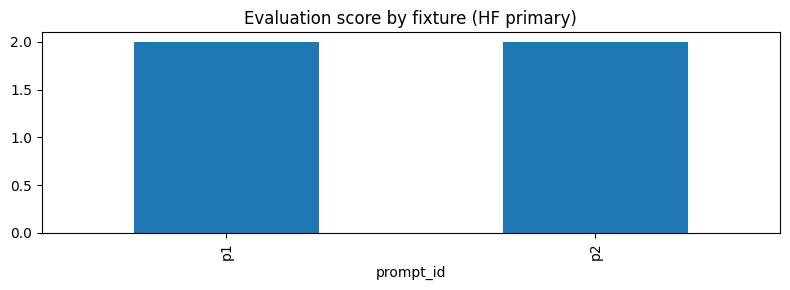

In [26]:
import pandas as pd

csv_path = ROOT / "reports" / "eval_results.csv"
if csv_path.is_file():
    df = pd.read_csv(csv_path)
    try:
        display(df.head(10))
    except NameError:
        print(df.head(10).to_string())
    try:
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(figsize=(8, 3))
        if len(df) and "score" in df.columns:
            df2 = df.copy()
            df2["score_f"] = pd.to_numeric(df2["score"], errors="coerce")
            df2.plot(x="prompt_id", y="score_f", kind="bar", ax=ax, legend=False)
            ax.set_title("Evaluation score by fixture (HF primary)")
            plt.tight_layout()
            plt.show()
    except Exception as e:
        print("Plot skipped:", e)
else:
    print("No CSV at", csv_path, "- run the evaluation subprocess cell first (with deps installed).")


**Takeaway.**  
 The `score` column reflects **automated** heuristics in `src/evaluation/metrics.py` (whether `mock`, `hf`, or `hf_alt`)—**not** investment quality.   
 Read `output_excerpt` against `build_recommendation_calc_payload` for the same fixture slots. With only two fixtures, treat the bar chart as **illustrative**.

---


## 13. Limitations *(critical reflection)*

**Rubric alignment:** **critical analysis** — scope, ethics, and honest assessment of what the system cannot do.

| Area | Limitation | Implication |
|------|------------|-------------|
| Capacity | 1.1B–1.5B instruct models | Nuanced planning advice is bounded; errors rise on edge cases. |
| Fine-tuning | Default `adapter_path: null` | No domain adapter unless trained and configured. |
| Data | No RAG or live feeds | Cannot ingest rates, fund facts, or tax law updates. |
| Debt model | Principal-only floor | Feasibility is illustrative, not amortisation-accurate. |
| Extraction | LLM JSON | Users may need Quick edit; retries capped by `extraction_retry_limit`. |
| Prompt techniques | Labels without prompt forks | Technique comparisons are not yet A/B tests at the prompt level. |

These limits are design boundaries, not bugs: stating them clearly satisfies typical rubric expectations on scope and ethics.

---


### File index (authoritative paths)

| Path | Role |
|------|------|
| `configs/models.yaml` | Primary and comparison HF IDs, quantization, token caps |
| `configs/dialogue.yaml` | Locale, extraction retry limit |
| `configs/training.yaml` | LoRA hyperparameters and data paths |
| `configs/evaluation.yaml` | Fixture path, metric weights, techniques list |
| `src/llm/prompts/recommend.jinja2` | Recommendation prompt template |
| `src/llm/prompts/dialogue_collect.jinja2` | Slot extraction prompt |
| `src/evaluation/fixtures/example_prompts.json` | Batch eval inputs |

---


## 14. Conclusion

### Summary

This project implements a **reproducible, modular pipeline** for a financial assistant, integrating:
- a Streamlit-based UI (`src/app/`)  
- structured dialogue orchestration (`src/dialogue/state_machine.py`)  
- local LLM backends (`src/llm/`)  
- schema-constrained recommendation generation (`src/finassist/schemas.py`)  
- deterministic debt calculations (`src/finassist/debt_calculations.py`)  

These components are combined through prompt templates (`recommend.jinja2`) to produce structured and interpretable outputs.

---

### Main Contribution

The key contribution is a **hybrid system design**:
- **deterministic Python logic** ensures reliable numerical reasoning  
- **LLM generation** provides flexible explanation and strategy  

This separation improves **grounding, transparency, and consistency**, addressing common weaknesses of purely neural approaches.

---

### Future Work

Potential extensions include:
- enabling LoRA fine-tuning (`scripts/train_lora.py`, `configs/training.yaml`) for domain adaptation  
- integrating prompt techniques (`techniques/*.txt`) into the generation pipeline for true A/B comparison  
- expanding evaluation coverage (`src/evaluation/fixtures/example_prompts.json`)  
- incorporating more realistic financial models (e.g., APR, compounding) within the deterministic layer  

---

### Evaluation Perspective

The system’s strengths align most strongly with:
- **Architecture:** clear modular design and separation of concerns  
- **Hybrid reasoning:** integration of symbolic computation with LLM generation  

Evaluation is supported through batch metrics and controlled comparisons, but should be interpreted alongside **qualitative review of outputs**.

---
